# Autoencoders — Scikit-Learn Pipeline

## Model: Dense Autoencoder (MLPRegressor)
- **Dataset**: CIFAR-10 — 10,000 train (subset) / 10,000 test, 3,072 features (32×32×3 flattened)
- **Task**: Reconstruct input images through bottleneck compression (self-supervised)
- **Framework showcase**: Bottleneck dimension sweep — how latent size affects reconstruction quality

## Evaluation Strategy
- **Metrics**: Reconstruction MSE, downstream KNN accuracy (K=5) on latent features
- **Visualizations**: Reconstruction grids, latent space t-SNE, training loss curves

## Pipeline
1. Load data + config
2. Simple dense autoencoder (baseline)
3. Training history + reconstruction visualization
4. Bottleneck dimension sweep (showcase)
5. Downstream classification on latent features
6. Compare results across dimensions
7. Performance benchmarks
8. Save results

In [1]:
# Step 1: Setup
"""
Imports, config, load preprocessed CIFAR-10 data
SK uses MLPRegressor as autoencoder (output = input, hidden bottleneck)
Using 10K subset — SK's MLPRegressor is full-batch, slow on 50K
"""

import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.visualization import (plot_training_history, plot_reconstruction_grid,
                                  plot_latent_space)
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsClassifier

# Config
RANDOM_STATE = 113
FRAMEWORK = "Scikit-Learn"
MODEL_NAME = "Autoencoder"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

IMAGE_SHAPE = (32, 32, 3)
N_FEATURES = 3072  # 32 * 32 * 3
LATENT_DIMS = [32, 64, 128, 256, 512]
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Load preprocessed data (normalized to [0,1], flattened)
X_train, X_test, y_train, y_test, metadata = load_processed_data('autoencoder')

# Subset for SK — full-batch MLPRegressor is slow on 50K samples
SK_SUBSET = 10000
rng = np.random.RandomState(RANDOM_STATE)
subset_idx = rng.choice(len(X_train), SK_SUBSET, replace=False)
X_train_sk = X_train[subset_idx]
y_train_sk = y_train[subset_idx]

# Banner
print("=" * 60)
print(f"[1/8] {FRAMEWORK} — {MODEL_NAME} Pipeline")
print("=" * 60)
print(f"Dataset: CIFAR-10 ({len(X_train_sk):,} train subset / {len(X_test):,} test)")
print(f"Features: {N_FEATURES} (32×32×3 flattened)")
print(f"Image shape: {IMAGE_SHAPE}")
print(f"Classes: {len(CLASS_NAMES)}")
print(f"Latent dims to test: {LATENT_DIMS}")
print(f"Pixel range: [{X_train_sk.min():.1f}, {X_train_sk.max():.1f}]")
print(f"Random state: {RANDOM_STATE}")

[1/8] Scikit-Learn — Autoencoder Pipeline
Dataset: CIFAR-10 (10,000 train subset / 10,000 test)
Features: 3072 (32×32×3 flattened)
Image shape: (32, 32, 3)
Classes: 10
Latent dims to test: [32, 64, 128, 256, 512]
Pixel range: [0.0, 1.0]
Random state: 113


In [2]:
# Step 2: Simple Dense Autoencoder (Baseline)

"""
MLPRegressor as autoencoder: input = output, hidden layers = bottleneck
Architecture: 3072 → 512 → 128 → 512 → 3072 (symmetric encoder/decoder)
"""

print("=" * 60)
print("[2/8] Simple Dense Autoencoder — Baseline")
print("=" * 60)

# Baseline: 128-dim bottleneck
baseline_ae = MLPRegressor(
    hidden_layer_sizes=(512, 128, 512),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    verbose=False
)

# Train — input IS the target (self-supervised reconstruction)
with track_performance() as perf:
    baseline_ae.fit(X_train_sk, X_train_sk)

# Reconstruct test set
X_test_recon = baseline_ae.predict(X_test)
X_test_recon = np.clip(X_test_recon, 0, 1)  # MLPRegressor can output outside [0,1]

# Reconstruction MSE
baseline_mse = np.mean((X_test - X_test_recon) ** 2)
baseline_mae = np.mean(np.abs(X_test - X_test_recon))

print(f"\nArchitecture: 3072 → 512 → 128 → 512 → 3072")
print(f"Epochs: {baseline_ae.n_iter_} (early stopped)")
print(f"Final loss: {baseline_ae.loss_:.6f}")
print(f"Training time: {perf['time']:.2f}s")
print(f"Peak memory: {perf['memory']:.2f} MB")
print(f"\nReconstruction Quality (test set):")
print(f"  MSE:  {baseline_mse:.6f}")
print(f"  MAE:  {baseline_mae:.6f}")
print(f"  RMSE: {np.sqrt(baseline_mse):.6f}")

# Count parameters
n_params_baseline = sum(c.size for c in baseline_ae.coefs_) + sum(i.size for i in baseline_ae.intercepts_)
print(f"\nParameters: {n_params_baseline:,}")

[2/8] Simple Dense Autoencoder — Baseline

Architecture: 3072 → 512 → 128 → 512 → 3072
Epochs: 97 (early stopped)
Final loss: 0.007143
Training time: 393.02s
Peak memory: 351.38 MB

Reconstruction Quality (test set):
  MSE:  0.013294
  MAE:  0.084109
  RMSE: 0.115301

Parameters: 3,281,024


[3/8] Visualizations


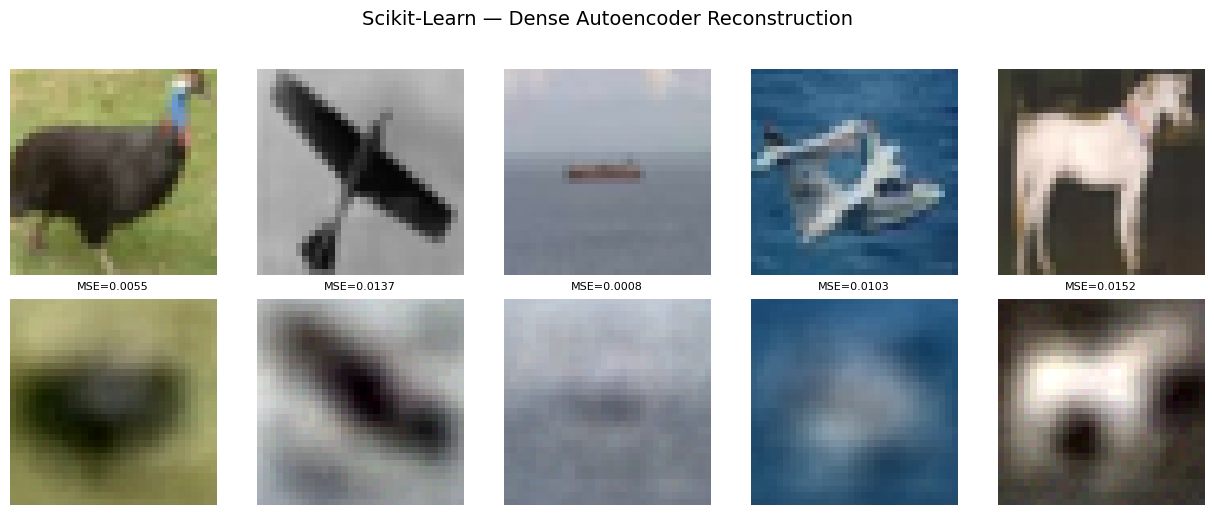

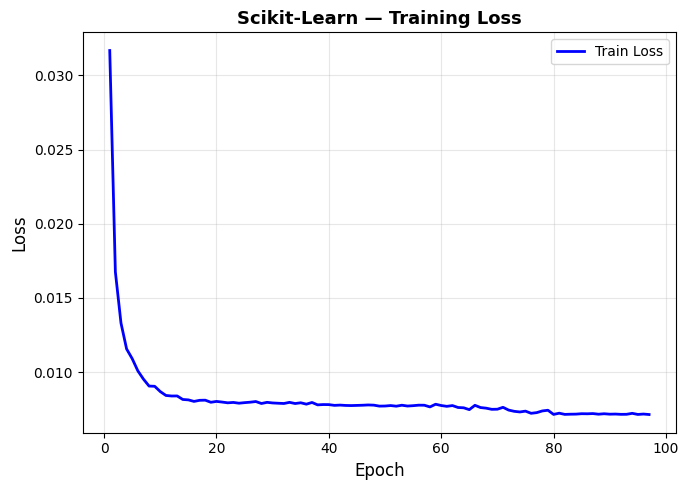


Train loss curve: 97 epochs
Final train loss: 0.007143
Best val R²:      0.776030


In [3]:
# Step 3: Visualizations

"""
Reconstruction grid (RGB) + training loss curve
MLPRegressor stores loss_curve_ (train MSE per epoch)
validation_scores_ is R² (not MSE) — different scale, plot train only
"""

print("=" * 60)
print("[3/8] Visualizations")
print("=" * 60)

# Reconstruction Grid
rng_viz = np.random.RandomState(RANDOM_STATE)
viz_idx = rng_viz.choice(len(X_test), 5, replace=False)

recon_dict = {128: X_test_recon[viz_idx]}
plot_reconstruction_grid(
    originals=X_test[viz_idx],
    reconstructions_dict=recon_dict,
    image_shape=IMAGE_SHAPE,
    n_samples=5,
    title='Dense Autoencoder Reconstruction',
    row_label_prefix='dim',
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/reconstruction_baseline.png'
)

# Training Loss Curve
# Train loss only — validation_scores_ is R² (different scale than MSE)
history = {
    'train_loss': baseline_ae.loss_curve_
}

plot_training_history(
    history=history,
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/training_history_baseline.png'
)

print(f"\nTrain loss curve: {len(baseline_ae.loss_curve_)} epochs")
print(f"Final train loss: {baseline_ae.loss_curve_[-1]:.6f}")
print(f"Best val R²:      {max(baseline_ae.validation_scores_):.6f}")

In [4]:
# Step 4: Bottleneck Dimension Sweep (Showcase)
"""
Train autoencoders at each latent dim in LATENT_DIMS
Architecture: symmetric encoder/decoder with one hidden layer each side
3072 → max(dim*2, 256) → dim → max(dim*2, 256) → 3072
Compare reconstruction MSE across bottleneck sizes
"""

print("=" * 60)
print("[4/8] Bottleneck Dimension Sweep — Showcase")
print("=" * 60)

sweep_results = {}

for dim in LATENT_DIMS:
    hidden = max(dim * 2, 256)
    arch = (hidden, dim, hidden)
    print(f"\n--- Latent dim={dim} | Architecture: 3072→{hidden}→{dim}→{hidden}→3072 ---")

    ae = MLPRegressor(
        hidden_layer_sizes=arch,
        activation='relu',
        solver='adam',
        max_iter=200,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        verbose=False
    )

    with track_performance() as p:
        ae.fit(X_train_sk, X_train_sk)

    recon = np.clip(ae.predict(X_test), 0, 1)
    mse = np.mean((X_test - recon) ** 2)
    n_params = sum(c.size for c in ae.coefs_) + sum(i.size for i in ae.intercepts_)

    sweep_results[dim] = {
        'model': ae,
        'recon': recon,
        'mse': mse,
        'epochs': ae.n_iter_,
        'train_time': p['time'],
        'n_params': n_params
    }

    print(f"  Epochs: {ae.n_iter_} | MSE: {mse:.6f} | "
          f"Params: {n_params:,} | Time: {p['time']:.1f}s")

# Summary table
print(f"\n{'=' * 60}")
print(f"{'Dim':>6} | {'MSE':>10} | {'Params':>12} | {'Epochs':>6} | {'Time':>8}")
print(f"{'-' * 6}-+-{'-' * 10}-+-{'-' * 12}-+-{'-' * 6}-+-{'-' * 8}")
for dim, r in sweep_results.items():
    print(f"{dim:>6} | {r['mse']:>10.6f} | {r['n_params']:>12,} | "
          f"{r['epochs']:>6} | {r['train_time']:>7.1f}s")

best_dim = min(sweep_results, key=lambda d: sweep_results[d]['mse'])
print(f"\nBest bottleneck: dim={best_dim} (MSE={sweep_results[best_dim]['mse']:.6f})")

[4/8] Bottleneck Dimension Sweep — Showcase

--- Latent dim=32 | Architecture: 3072→256→32→256→3072 ---
  Epochs: 155 | MSE: 0.023326 | Params: 1,592,864 | Time: 409.0s

--- Latent dim=64 | Architecture: 3072→256→64→256→3072 ---
  Epochs: 143 | MSE: 0.013981 | Params: 1,609,280 | Time: 301.4s

--- Latent dim=128 | Architecture: 3072→256→128→256→3072 ---
  Epochs: 115 | MSE: 0.010473 | Params: 1,642,112 | Time: 258.9s

--- Latent dim=256 | Architecture: 3072→512→256→512→3072 ---
  Epochs: 152 | MSE: 0.008676 | Params: 3,412,224 | Time: 707.6s

--- Latent dim=512 | Architecture: 3072→1024→512→1024→3072 ---
  Epochs: 137 | MSE: 0.007150 | Params: 7,345,664 | Time: 1368.9s

   Dim |        MSE |       Params | Epochs |     Time
-------+------------+--------------+--------+---------
    32 |   0.023326 |    1,592,864 |    155 |   409.0s
    64 |   0.013981 |    1,609,280 |    143 |   301.4s
   128 |   0.010473 |    1,642,112 |    115 |   258.9s
   256 |   0.008676 |    3,412,224 |    152 | 

[5/8] Downstream Classification + Latent Space

--- Latent dim=128 ---
Latent shape: train=(10000, 128), test=(10000, 128)
KNN(K=5) accuracy on latent features: 0.3427


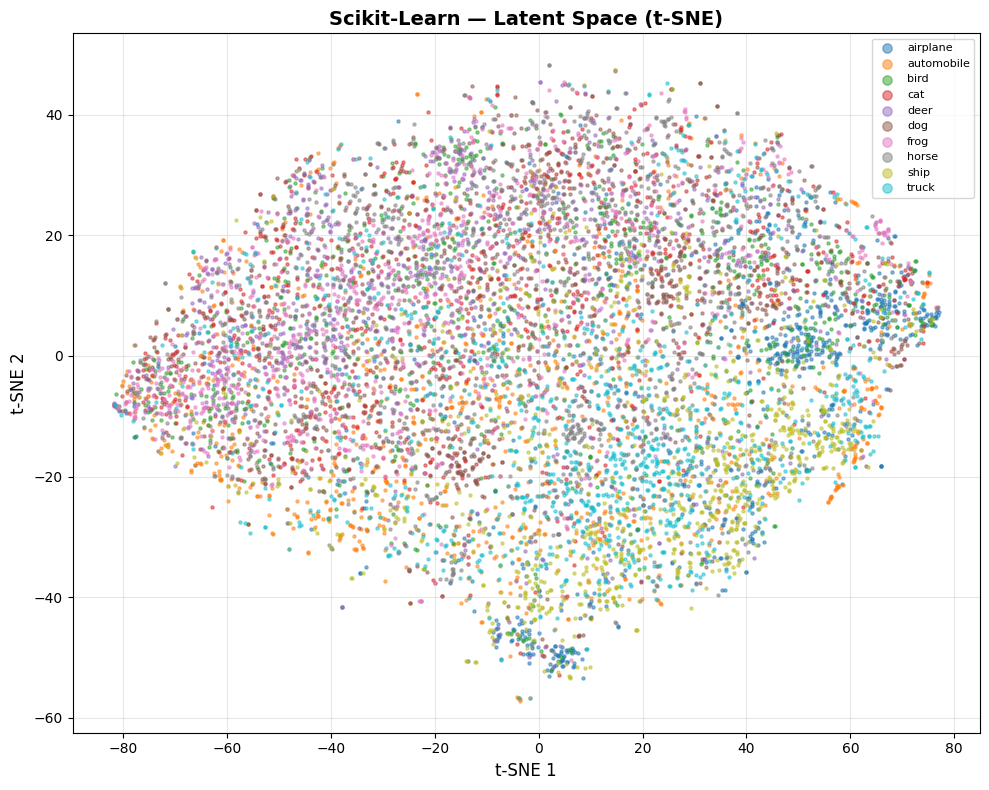


--- Latent dim=512 ---
Latent shape: train=(10000, 512), test=(10000, 512)
KNN(K=5) accuracy on latent features: 0.3135


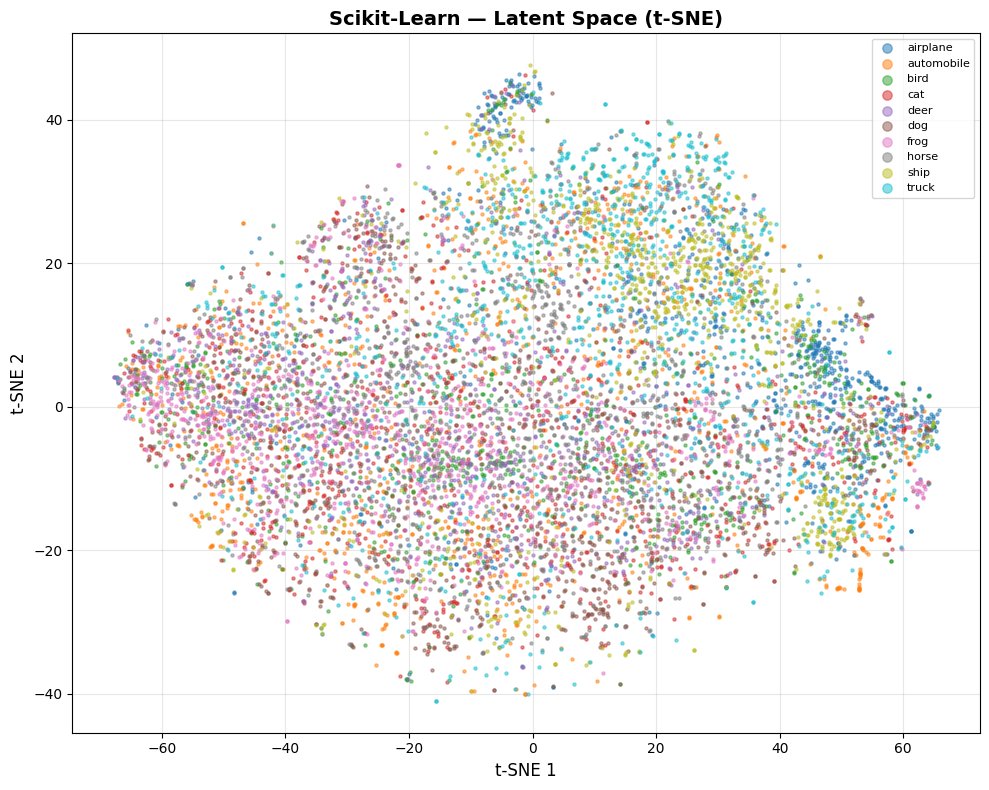

In [5]:
# Step 5: Downstream Classification + Latent Space

"""
Extract latent features via manual encoder forward pass
MLPRegressor doesn't expose intermediate layers — walk through
coefs_[0] and intercepts_[0] (input→first hidden = encoder)
Then KNN(K=5) on latent features to measure representation quality
"""

print("=" * 60)
print("[5/8] Downstream Classification + Latent Space")
print("=" * 60)

# Use best model from sweep (dim=512) AND baseline (dim=128) for comparison
dims_to_eval = [128, 512]

for dim in dims_to_eval:
    if dim == 128:
        model = baseline_ae
    else:
        model = sweep_results[dim]['model']

    """
    Manual encoder forward pass through first half of network
    Architecture: input → hidden1 → bottleneck → hidden2 → output
    Encoder = layers 0 and 1 (input→hidden1, hidden1→bottleneck)
    coefs_[0]: (3072, hidden1), coefs_[1]: (hidden1, bottleneck)
    """
    n_layers = len(model.coefs_)
    n_encoder_layers = n_layers // 2  # symmetric architecture

    def encode(X, model, n_encoder_layers):
        """Manual forward pass through encoder layers only."""
        h = X
        for i in range(n_encoder_layers):
            h = h @ model.coefs_[i] + model.intercepts_[i]
            h = np.maximum(h, 0)  # ReLU activation
        return h

    # Extract latent features
    latent_train = encode(X_train_sk, model, n_encoder_layers)
    latent_test = encode(X_test, model, n_encoder_layers)

    print(f"\n--- Latent dim={dim} ---")
    print(f"Latent shape: train={latent_train.shape}, test={latent_test.shape}")

    # KNN downstream classification
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(latent_train, y_train_sk)
    knn_acc = knn.score(latent_test, y_test)
    print(f"KNN(K=5) accuracy on latent features: {knn_acc:.4f}")

    # Latent space visualization (t-SNE on test set — 10K is manageable)
    plot_latent_space(
        latent_vectors=latent_test,
        labels=y_test,
        class_names=CLASS_NAMES,
        framework=FRAMEWORK,
        method='tsne',
        save_path=f'{RESULTS_DIR}/latent_space_dim{dim}.png'
    )

[6/8] Compare Results Across Dimensions


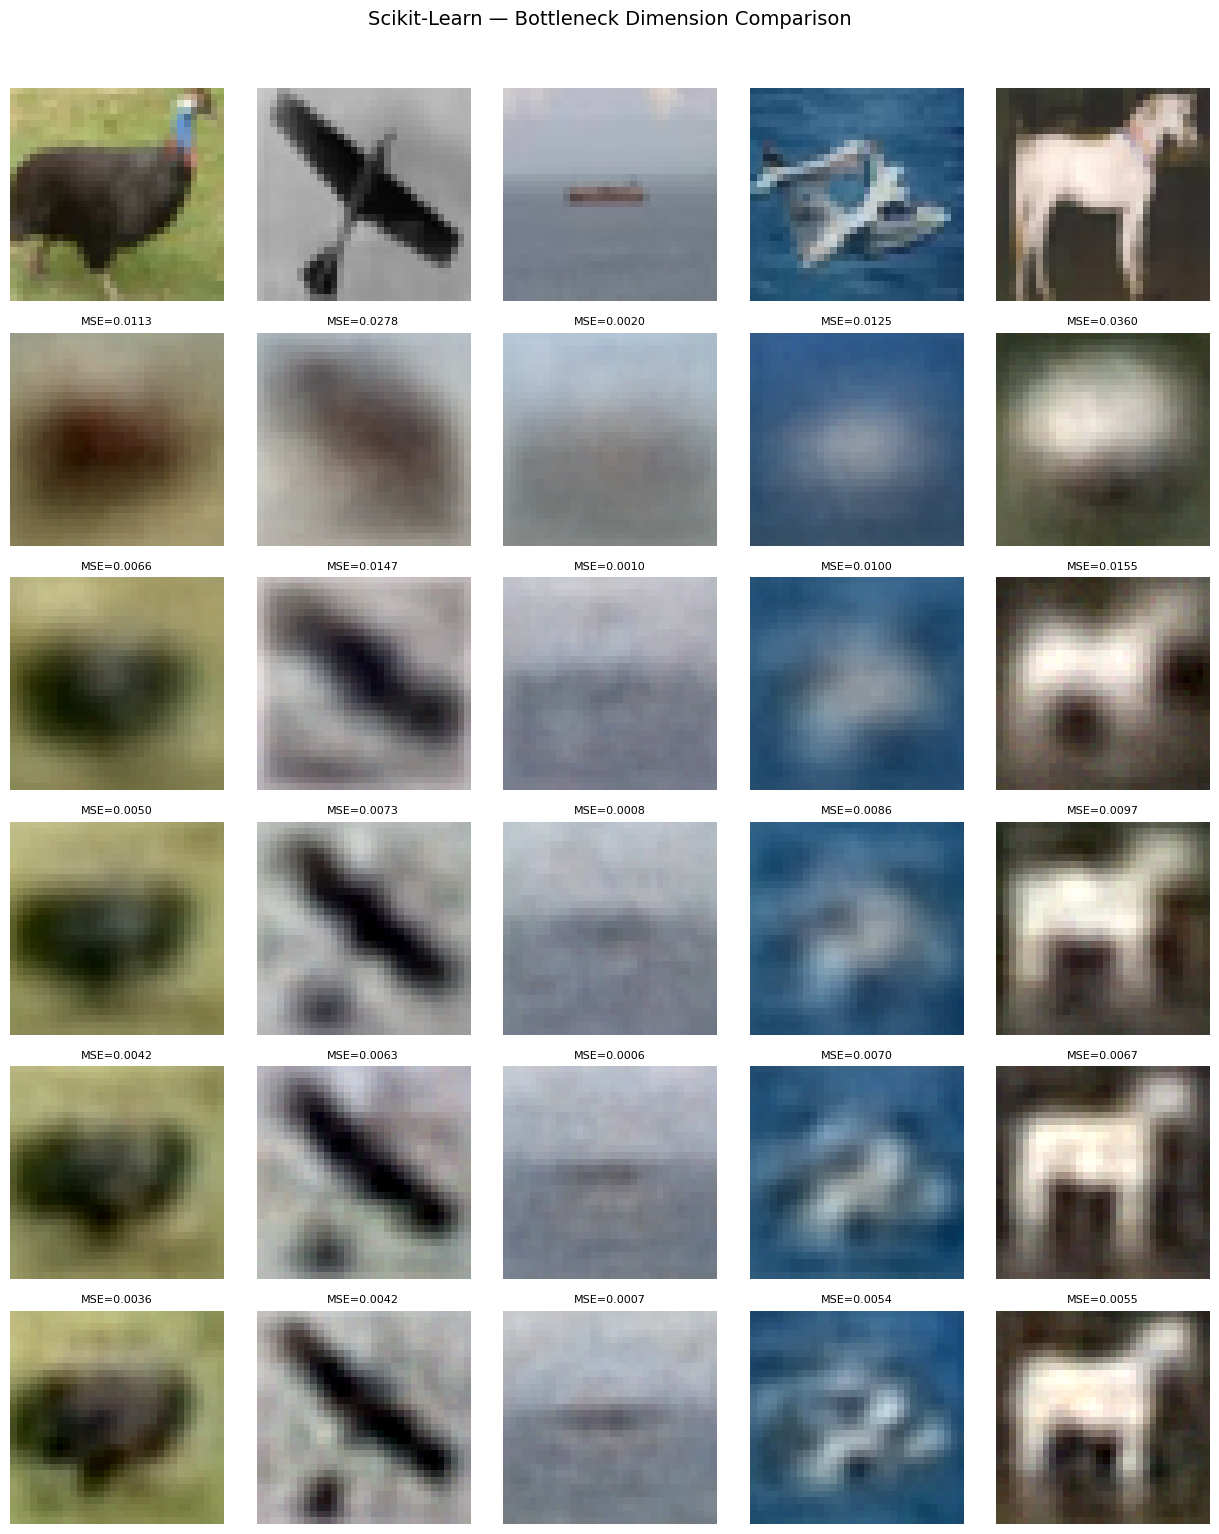

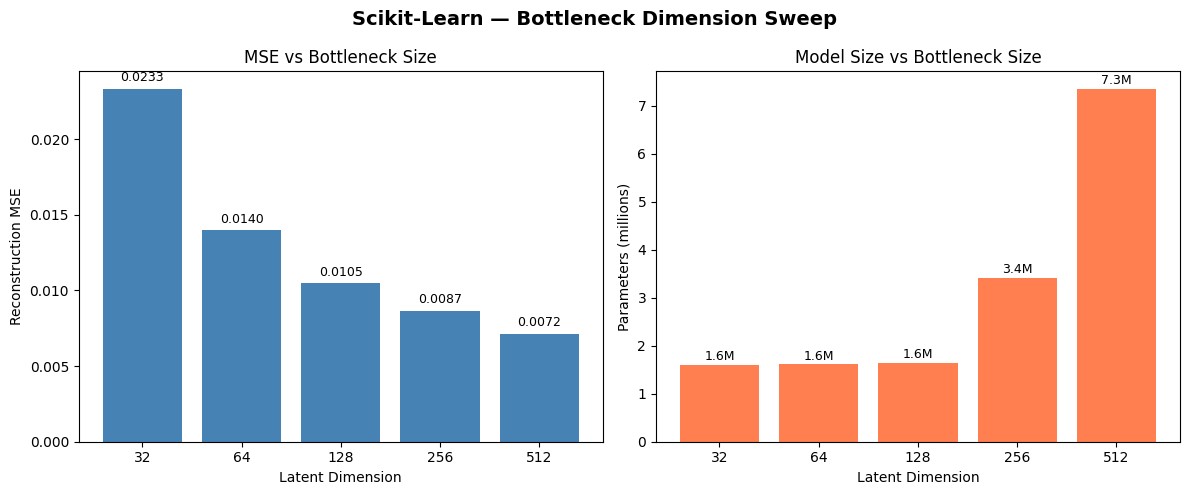


   Dim |        MSE |     Params |     Time |  Compression
-------+------------+------------+----------+-------------
    32 |   0.023326 |       1.6M |   409.0s |       96.0x
    64 |   0.013981 |       1.6M |   301.4s |       48.0x
   128 |   0.010473 |       1.6M |   258.9s |       24.0x
   256 |   0.008676 |       3.4M |   707.6s |       12.0x
   512 |   0.007150 |       7.3M |  1368.9s |        6.0x

Key insight: dim=512 wins MSE (0.007150) but dim=128 offers 24x compression at only 46.5% higher MSE


In [6]:
# Step 6: Compare Results Across Dimensions
"""
Reconstruction grid comparing all bottleneck sizes side-by-side
Bar charts for MSE and parameter count across dims
"""

print("=" * 60)
print("[6/8] Compare Results Across Dimensions")
print("=" * 60)

# Reconstruction grid: same 5 images across all dim
rng_viz = np.random.RandomState(RANDOM_STATE)
viz_idx = rng_viz.choice(len(X_test), 5, replace=False)

recon_dict_all = {}
for dim, r in sweep_results.items():
    recon_dict_all[dim] = r['recon'][viz_idx]

plot_reconstruction_grid(
    originals=X_test[viz_idx],
    reconstructions_dict=recon_dict_all,
    image_shape=IMAGE_SHAPE,
    n_samples=5,
    title='Bottleneck Dimension Comparison',
    row_label_prefix='dim',
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/reconstruction_sweep.png'
)

# Bar charts: MSE and params
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

dims = list(sweep_results.keys())
mses = [sweep_results[d]['mse'] for d in dims]
params = [sweep_results[d]['n_params'] for d in dims]
times = [sweep_results[d]['train_time'] for d in dims]

# MSE bar chart
axes[0].bar(range(len(dims)), mses, color='steelblue')
axes[0].set_xticks(range(len(dims)))
axes[0].set_xticklabels(dims)
axes[0].set_xlabel('Latent Dimension')
axes[0].set_ylabel('Reconstruction MSE')
axes[0].set_title('MSE vs Bottleneck Size')
for i, (d, m) in enumerate(zip(dims, mses)):
    axes[0].text(i, m + 0.0005, f'{m:.4f}', ha='center', fontsize=9)

# Parameter count bar chart
axes[1].bar(range(len(dims)), [p / 1e6 for p in params], color='coral')
axes[1].set_xticks(range(len(dims)))
axes[1].set_xticklabels(dims)
axes[1].set_xlabel('Latent Dimension')
axes[1].set_ylabel('Parameters (millions)')
axes[1].set_title('Model Size vs Bottleneck Size')
for i, p in enumerate(params):
    axes[1].text(i, p / 1e6 + 0.1, f'{p / 1e6:.1f}M', ha='center', fontsize=9)

plt.suptitle(f'{FRAMEWORK} — Bottleneck Dimension Sweep', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/sweep_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table with all metrics
print(f"\n{'Dim':>6} | {'MSE':>10} | {'Params':>10} | {'Time':>8} | {'Compression':>12}")
print(f"{'-' * 6}-+-{'-' * 10}-+-{'-' * 10}-+-{'-' * 8}-+-{'-' * 12}")
for dim in dims:
    r = sweep_results[dim]
    compression = N_FEATURES / dim
    print(f"{dim:>6} | {r['mse']:>10.6f} | {r['n_params'] / 1e6:>9.1f}M | "
          f"{r['train_time']:>7.1f}s | {compression:>10.1f}x")

print(f"\nKey insight: dim=512 wins MSE ({sweep_results[512]['mse']:.6f}) but "
      f"dim=128 offers 24x compression at only "
      f"{((sweep_results[128]['mse'] - sweep_results[512]['mse']) / sweep_results[512]['mse'] * 100):.1f}% "
      f"higher MSE")

In [ ]:
# Step 7: Performance Benchmarks

"""
Track inference speed + model size for the best model (dim=128)
Using dim=128 as the "production" pick — best compression/quality tradeoff
"""

print("=" * 60)
print("[7/8] Performance Benchmarks")
print("=" * 60)

# Use dim=128 as the representative model (baseline)
best_model = baseline_ae

# Inference speed — reconstruction
inference_stats = track_inference(
    predict_fn=lambda X: np.clip(best_model.predict(X), 0, 1),
    X=X_test,
    n_runs=10
)

# Model size
model_size = get_model_size(best_model, framework='sklearn')

print(f"\nModel: Dense AE (3072→512→128→512→3072)")
print(f"Parameters: {n_params_baseline:,}")
print(f"\nInference (reconstruction):")
print(f"  Total time: {inference_stats['total_time'] * 1000:.2f} ms ({len(X_test):,} samples)")
print(f"  Per sample:  {inference_stats['per_sample_us']:.2f} µs")
print(f"  Throughput:  {inference_stats['samples_per_sec']:,.0f} samples/sec")
print(f"\nModel size: {model_size / 1024:.2f} KB")

[7/8] Performance Benchmarks

Model: Dense AE (3072→512→128→512→3072)
Parameters: 3,281,024

Inference (reconstruction):
  Total time: 441.72 ms (10,000 samples)
  Per sample:  44.17 µs
  Throughput:  22,639 samples/sec

Model size: 38459.10 KB


In [12]:
# Step 8: Save Results

"""
Save best model results using build_results_dict
Using dim=128 baseline as representative (best compression/quality tradeoff)
"""

print("=" * 60)
print("[8/8] Save Results")
print("=" * 60)

# Build test metrics dict (reconstruction, not classification)
test_metrics = {
    'reconstruction_mse': baseline_mse,
    'reconstruction_mae': baseline_mae,
    'reconstruction_rmse': np.sqrt(baseline_mse)
}

# Weight-only model size (coefs + intercepts)
weight_size = sum(c.nbytes for c in best_model.coefs_) + sum(i.nbytes for i in best_model.intercepts_)

results = build_results_dict(
    framework=FRAMEWORK,
    model_name=MODEL_NAME,
    test_metrics=test_metrics,
    perf=perf,
    inference_stats=inference_stats,
    model_size=weight_size,
    latent_dim=128,
    architecture='3072-512-128-512-3072',
    architecture_type='dense',
    n_params=n_params_baseline,
    epochs=baseline_ae.n_iter_,
    downstream_knn_accuracy=0.3427,
    compression_ratio=24.0,
    training_subset=SK_SUBSET
)

save_results(results, f'{RESULTS_DIR}/sk_autoencoder_results.json')
add_result('autoencoder', results)
print_comparison('autoencoder')

[8/8] Save Results
    Results saved to: results/sk_autoencoder_results.json\metrics.json
    Added 'Scikit-Learn' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\autoencoder.json
    Frameworks: 1 recorded

CROSS-FRAMEWORK COMPARISON: AUTOENCODER
Metric                                   Scikit-Learn
-----------------------------------------------------
model                                     Autoencoder
training_time                                 6.6 min
inference_time_per_sample_us                 44.17 µs
model_size_bytes                             12.52 MB
peak_memory_mb                              351.38 MB
reconstruction_mse                             0.0133
reconstruction_mae                             0.0841
reconstruction_rmse                            0.1153
latent_dim                                        128
architecture                    3072-512-128-512-3072
architecture_type                               dense
n_params      